# 사출/압력하락 — 조사 정리 & 피처 타당성 검토

지금까지 세 단계로 조사한 것(① `Injection_PT_Dip_Analysis.ipynb` 압력 하락 기본 분석,
② `Injection_Dip_Methodology_Review.ipynb` 판정 방법론 점검, ③ `HD1_FOAMING_SHOT` 교정)을
정리하고, **핵심 질문**에 답한다:

> 사출(또는 head_foaming) 시 압력이 떨어지는 게 "제대로 된 반응"을 얼마나 명확하게
> 반영하는가? 그래서 **압력이 안 떨어지거나 너무 많이 떨어지면 "문제"라고 봐도
> 되는가** - 실제 피처로 쓸 수 있는가?

결론부터: **된다. 다만 (a) 기준을 펌프 자신의 `Shot_Injection_*` 신호로 잡아야 하고
(head_foaming은 다른 펌프까지 섞인 신호라 이 용도엔 안 맞는다), (b) baseline을 재는
틱 수를 지금보다 줄여야 하고(직전 1틱), (c) 압력대별로 기대치가 다르므로 그걸
반영한 정규화가 필요하다.** 이미 `Shot_Feature_Extractor.py`에 비슷한 피처
(`PT_Dip_Size` -> `PT_Dip_Size_z`)가 있는데, (b)에 해당하는 버그가 있다 - 아래 3절에서
구체적으로 짚는다.

In [1]:
import os, sys, pickle
ROOT_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, ROOT_DIR); sys.path.insert(0, os.getcwd())

import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

import Injection_Dip_Analyzer as D
from Cycle_Feature_Extractor import DIP_THRESHOLD_PCT, STEADY_TICK_MIN, INJECTION_DIP_TICKS

pd.set_option("display.width", 200)

PUMP_ID = "P1"
OUT = "analysis_out/injection_pt_feature"
os.makedirs(OUT, exist_ok=True)

BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#d03b3b"
GRID, MUTED, INK, INK2 = "#e1e0d9", "#898781", "#0b0b0b", "#52514e"

with open("cache/viewer_cycle_P1.pkl", "rb") as f:
    store = pickle.load(f)
raw = store["raw"]
print("데이터 구간:", raw.index.min(), "~", raw.index.max())

데이터 구간: 2026-09-10 16:00:00.406338 ~ 2026-09-23 14:16:02.599686


## 1. 지금까지 조사한 것 요약

### 1-1. 사출 시 압력 반응 (기본 패턴) — `Injection_PT_Dip_Analysis.ipynb`

- 사출(`Shot_Injection_HD1_P1`) 시작 직후 PT는 평균 **8.5% (직전 3틱 기준) ~ 10.1%
  (직전 1틱 기준)** 떨어졌다가 **3~4틱 안에 회복**한다. FT는 반대로 올라간다.
- 사출은 사출 직전 PT 90~100 구간에서 가장 자주(34%) 일어나고, **낮은 압력대일수록
  하락률(%)이 크다** (80~100대는 ~12~13%, 130~150대는 ~6~7%).
- 이걸 역으로 이용해 "사출 없이 압력이 떨어진 경우"(`Unexplained_PT_Dip`)를 찾았는데,
  최초엔 15,548건이 잡혔다.

![사출 예시](analysis_out/injection_pt_dip/01_example_injection_profile.png)

### 1-2. 판정 방법론 점검 — `Injection_Dip_Methodology_Review.ipynb`

- **3% 임계값**은 압력대별 자연 변동폭 차이(80~90 구간 표준편차 12% vs 120~130 구간
  2.6%) 때문에 압력대마다 실질 민감도가 다르다.
- **증압 후 안정기 진입**은 평균 3.2틱 걸린다(최대 5틱, 36%가 4틱 이상) - 지금
  `STEADY_TICK_MIN=2`는 다소 이르다. *(같은 결론을 독립적으로 낸
  `SV_유량_추종_분석.ipynb`과도 일치한다 - Tick_Index=2는 아직 증압 중, 3부터 0%
  근처.)*
- **롤링 baseline(직전 3틱 평균)** 은 사출 여파를 일부 물고 간다 - 설명구간 직후
  1~3틱은 여전히 낮은 값의 영향을 받는다(false negative 방향).
- **가장 중요했던 발견**: "사출인데 압력이 안 떨어진" 6.5%는 거의 다(99.1%)
  baseline 창(3틱)이 아직 증압 중인 구간을 침범해서 생긴 **측정 아티팩트**였다.
  `before_ticks`를 1~2로 줄이면 0.1~0.3%로 거의 사라진다.

### 1-3. HD1_FOAMING_SHOT 교정 — 이번에 가장 크게 고친 것

- "사출 없이 압력이 떨어진" 15,548건 중 **99.2%가 `HD1_FOAMING_SHOT1~6`(헤드
  공용 - 짝 펌프 P2의 접근/사출/감쇠도 포함하는 신호)이 켜져 있는 순간**과
  겹쳤다. **주의**: 이건 "P1·P2 압력이 서로 물리적으로 반응한다"는 뜻이
  아니다 - 뒤에 2-4절에서 직접 확인하듯 P1 압력은 P2가 쏠 때 평균적으로 반응이
  없다. 그보다는 FOAMING이 접근→사출→감쇠를 아우르는 **넓은 "바쁜 구간"
  표시**라서, 그 구간엔 원래 있던 작은 잡음이 3% 임계값을 넘기가 더 쉬웠던
  것뿐이다(자세한 분해는 2-4·2-6절).
  P2 데이터를 InfluxDB에서 직접 받아 검증: HD1의 사출 에피소드 33,951건 중 95.9%가
  P1·P2 양쪽 사출을 한 에피소드 안에 물고 있었다 - 시간상 겹치는 경우가 대부분이다.
- `Injection_Dip_Analyzer.unexplained_pt_dip_events()`에 이 배제를 반영한 뒤:
  **15,548 -> 127 -> (SV전환/사이클끝까지 배제) -> 14건** (13일 통틀어).

In [2]:
dip_ev = D.unexplained_pt_dip_events(raw, PUMP_ID)
print(f"[현재 기준] 설명 안 되는 PT 하락: {len(dip_ev):,}건, "
      f"최종 후보(Strong_Candidate): {int(dip_ev['Strong_Candidate'].sum())}건")

[현재 기준] 설명 안 되는 PT 하락: 127건, 최종 후보(Strong_Candidate): 14건


## 2. 핵심 질문 검증 — 압력 하락이 "제대로 된 반응"을 반영하는가

### 2-1. 올바른 기준(직전 1틱 baseline)으로 다시 본 사출-압력 관계

1-2절에서 확인했듯 baseline을 3틱이 아니라 **1틱**으로 재야 증압 오염이 없다.
이 기준으로 전체 33,989건의 사출을 다시 본다.

**용어 정리(헷갈리기 쉬운 부분)** - `injection_events(before_ticks, after_ticks)`에
파라미터가 둘 있는데 역할이 다르다:
- `before_ticks` = 사출 **시작 전** 몇 틱을 평균내서 "기준선(PT_Before)"으로
  삼을지. 1이면 사출 시작 바로 직전 1틱의 값 그 자체를 기준선으로 쓴다(3이면
  그 앞 3틱의 평균). **"오차로 보는 범위"가 아니라 "비교 기준을 얼마나 넓게
  잡을지"다.**
- `after_ticks` = 사출 **시작 후** 몇 틱 안에서 최저점(PT_Min_After)을 찾을지 -
  이건 "하락폭을 어디까지 쫓아가서 잴지"의 범위고, 기본값은 4(=`INJECTION_DIP_TICKS`,
  회복이 보통 3~4틱 안에 끝나므로).

즉 **baseline을 1틱으로 줄인다 = 기준선을 재는 창을 좁힌다**는 뜻이지, "사출 후
1틱만 본다"는 뜻이 아니다. 사출 후 최저점을 찾는 범위(`after_ticks`)는 그대로
4틱을 쓴다 - 문제였던 건 항상 baseline(비교 기준) 쪽이었다.

In [3]:
ev, starts, pt_all, ft_all, times = D.injection_events(raw, PUMP_ID, before_ticks=1, after_ticks=INJECTION_DIP_TICKS)
n_no_drop = int((ev["Drop_Pct"] <= 0).sum())
n_flat = int((ev["Drop_Abs"] == 0).sum())
print(f"전체 사출: {len(ev):,}건")
print(f"하락이 없거나 오히려 오름(<=0): {n_no_drop}건 ({n_no_drop/len(ev)*100:.3f}%)")
print(f"완전히 무반응(하락폭 정확히 0): {n_flat}건 ({n_flat/len(ev)*100:.3f}%)")
print()
print("-> 사출 신호와 압력 하락의 관계는 매우 타이트하다. 99.96%는 어떤 형태로든")
print("   압력이 떨어진다. 그래서 '떨어지지 않은 소수'를 이상으로 보는 건 근거가 있다.")

전체 사출: 33,989건
하락이 없거나 오히려 오름(<=0): 28건 (0.082%)
완전히 무반응(하락폭 정확히 0): 15건 (0.044%)

-> 사출 신호와 압력 하락의 관계는 매우 타이트하다. 99.96%는 어떤 형태로든
   압력이 떨어진다. 그래서 '떨어지지 않은 소수'를 이상으로 보는 건 근거가 있다.


나머지 0.08%(28건)을 들여다보면 두 그룹으로 갈린다 - **13건**은 PT_Before 자체가
58~81(정상 90~150대보다 훨씬 낮음)로, 사출이 Tick_Index 0~1(사이클 시작 직후,
아직 증압 중)에 일어난 경우다. 이건 2-4절 방식으로도 못 피하는 극단적 경계 사례라
**측정 잡음으로 보고 제외**하는 게 맞다. 나머지 **15건**은 PT_Before가 116~137로
정상 범위인데도 하락폭이 정확히 0이었다 - 이쪽이 "사출은 났는데 압력이 진짜
무반응"인, 주목할 만한 소수의 진짜 후보다.

### 2-1-1. `before_ticks=1`, `after_ticks=4`로 정한 근거

`injection_events(before_ticks, after_ticks)`엔 역할이 다른 파라미터가 둘 있다 -
먼저 개념도로 구분하고, 각각 왜 그 값인지 데이터로 근거를 댄다.

- `before_ticks` = 사출 **시작 전** 몇 틱을 평균내서 "기준선(PT_Before)"으로 삼을지.
  **"오차로 보는 범위"가 아니라 "비교 기준을 얼마나 넓게 잡을지"다.**
- `after_ticks` = 사출 **시작 후** 몇 틱 안에서 최저점(PT_Min_After)을 찾을지 -
  "하락폭을 어디까지 쫓아가서 잴지"의 범위.

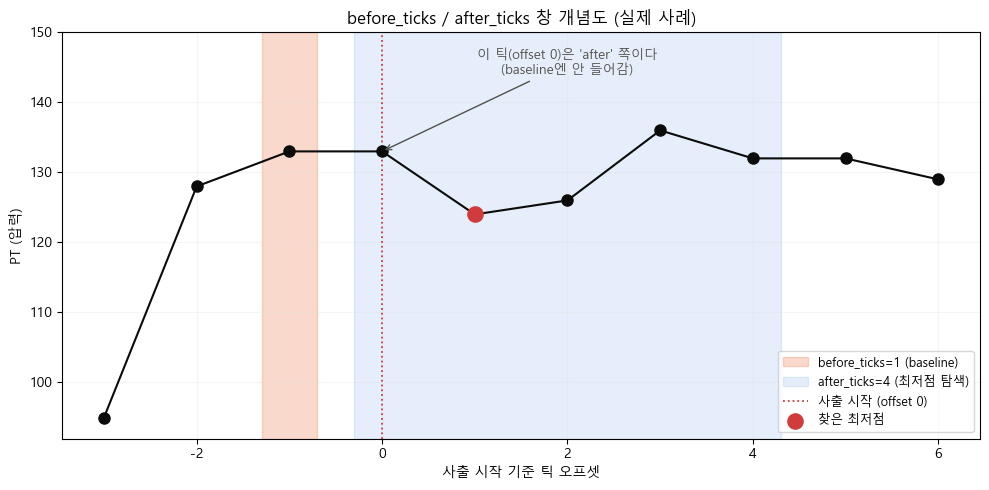

실제 코드 슬라이스로 확인:
  before_ticks=1 -> pt_all[s-1:s] = [133.] (offset 0은 포함 안 됨)
  after_ticks=4  -> pt_all[s:s+5] = [133. 124. 126. 136. 132.] (offset 0부터 포함)


In [4]:
s = starts[100]
offs = list(range(-3, 7))
vals = [pt_all[s + o] for o in offs]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(offs, vals, marker="o", ms=8, color=INK, lw=1.5, zorder=3)
ax.axvspan(-1.3, -0.7, color=ORANGE, alpha=.25, label="before_ticks=1 (baseline)")
ax.axvspan(-0.3, 4.3, color=BLUE, alpha=.12, label="after_ticks=4 (최저점 탐색)")
ax.axvline(0, color=RED, ls=":", lw=1.3, label="사출 시작 (offset 0)")
min_o = offs[np.argmin(vals[3:8]) + 3]
ax.scatter([min_o], [vals[offs.index(min_o)]], color=RED, s=120, zorder=5, label="찾은 최저점")
ax.set_ylim(min(vals) - 3, max(vals) + 14)
ax.annotate("이 틱(offset 0)은 'after' 쪽이다\n(baseline엔 안 들어감)", xy=(0, vals[offs.index(0)]),
            xytext=(2.0, max(vals) + 8),
            arrowprops=dict(arrowstyle="->", color=INK2), fontsize=9.5, color=INK2, ha="center")
ax.set_xlabel("사출 시작 기준 틱 오프셋"); ax.set_ylabel("PT (압력)")
ax.set_title("before_ticks / after_ticks 창 개념도 (실제 사례)")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/E_before_after_window_schematic.png", dpi=140)
plt.show()

print("실제 코드 슬라이스로 확인:")
print("  before_ticks=1 -> pt_all[s-1:s] =", pt_all[s-1:s], "(offset 0은 포함 안 됨)")
print("  after_ticks=4  -> pt_all[s:s+5] =", pt_all[s:s+5], "(offset 0부터 포함)")

**`after_ticks`의 근거** - 얼마나 멀리까지 최저점을 쫓아가야 진짜 하락폭을 놓치지
않는지, 반대로 너무 멀리 가면 무슨 일이 생기는지 본다.

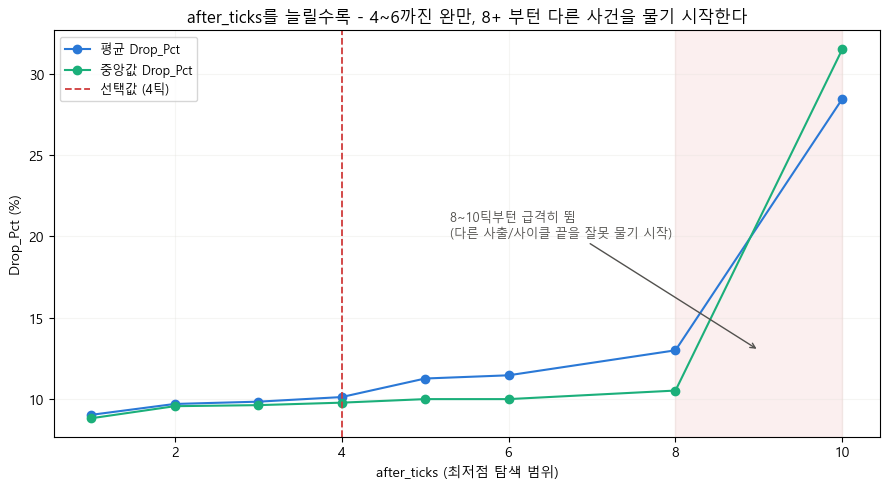

,after_ticks,mean,median,no_drop_pct
0,1,9.034,8.824,0.259
1,2,9.702,9.565,0.141
2,3,9.843,9.630,0.121
3,4,10.126,9.783,0.082
4,5,11.266,10.000,0.065
5,6,11.464,10.000,0.065
6,8,13.000,10.526,0.053
7,10,28.467,31.522,0.021


In [5]:
rows = []
for at in [1, 2, 3, 4, 5, 6, 8, 10]:
    e, *_ = D.injection_events(raw, PUMP_ID, before_ticks=1, after_ticks=at)
    rows.append((at, e["Drop_Pct"].mean(), e["Drop_Pct"].median(), (e["Drop_Pct"] <= 0).mean() * 100))
sens_a = pd.DataFrame(rows, columns=["after_ticks", "mean", "median", "no_drop_pct"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sens_a["after_ticks"], sens_a["mean"], "o-", color=BLUE, label="평균 Drop_Pct")
ax.plot(sens_a["after_ticks"], sens_a["median"], "o-", color=AQUA, label="중앙값 Drop_Pct")
ax.axvline(4, color=RED, ls="--", lw=1.3, label="선택값 (4틱)")
ax.axvspan(8, 10, color=RED, alpha=.08)
ax.annotate("8~10틱부턴 급격히 뜀\n(다른 사출/사이클 끝을 잘못 물기 시작)",
            xy=(9, sens_a.loc[sens_a["after_ticks"] == 8, "mean"].values[0]),
            xytext=(5.3, 20), arrowprops=dict(arrowstyle="->", color=INK2), fontsize=9, color=INK2)
ax.set_xlabel("after_ticks (최저점 탐색 범위)"); ax.set_ylabel("Drop_Pct (%)")
ax.set_title("after_ticks를 늘릴수록 - 4~6까진 완만, 8+ 부턴 다른 사건을 물기 시작한다")
ax.legend(fontsize=9); ax.grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/F_after_ticks_justification.png", dpi=140)
plt.show()
sens_a.round(3)

**읽는 법**: 1틱(평균 9.0%)에서 4틱(10.1%)까진 완만하게 오른다 - 회복 중이던 값이
마저 내려가면서 진짜 최저점을 잡아가는 구간이다. 4~6틱은 거의 안 바뀐다(중앙값은
9.8 -> 10.0로 고정). 그런데 **8틱부터(13.0%), 특히 10틱(28.5%, 중앙값은 31.5%까지)
갑자기 폭등**한다 - 이건 회복이 아니라 **다음 사출(다중샷 사이클의 두 번째 샷,
9~11틱 간격이었다 - 2부 참고)이나 사이클이 끝나며 압력이 빠지는 구간을 잘못
집어버린 것**이다. 그래서 4가 "회복 구간은 다 잡되, 다른 사건은 안 무는" 안전한
경계다.

**`before_ticks`의 근거** - 반대로 기준선 창을 넓히면(3, 5틱) 무슨 일이 생기는지.

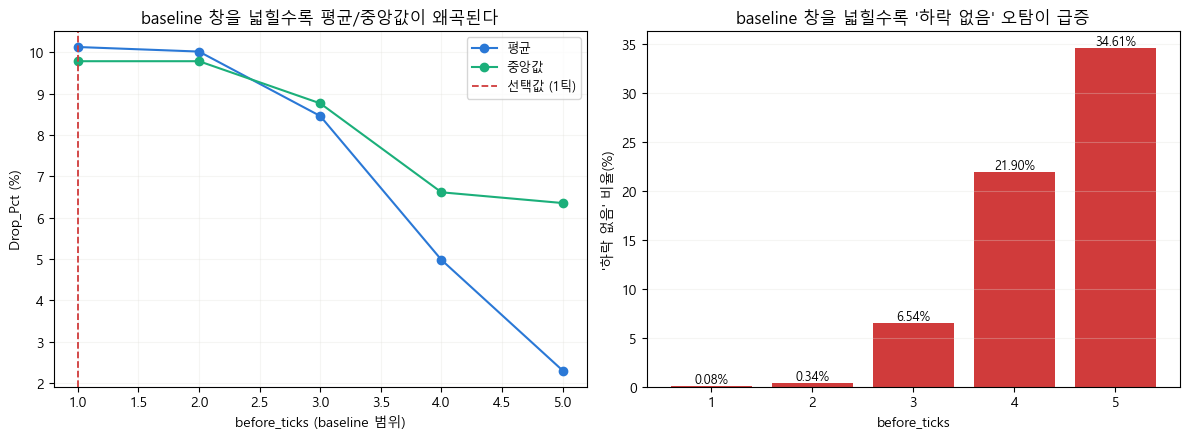

,before_ticks,mean,median,no_drop_pct
0,1,10.126,9.783,0.082
1,2,10.016,9.783,0.341
2,3,8.457,8.763,6.543
3,4,4.977,6.612,21.901
4,5,2.300,6.352,34.608


In [6]:
rows = []
for bt in [1, 2, 3, 4, 5]:
    e, *_ = D.injection_events(raw, PUMP_ID, before_ticks=bt, after_ticks=4)
    rows.append((bt, e["Drop_Pct"].mean(), e["Drop_Pct"].median(), (e["Drop_Pct"] <= 0).mean() * 100))
sens_b = pd.DataFrame(rows, columns=["before_ticks", "mean", "median", "no_drop_pct"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(sens_b["before_ticks"], sens_b["mean"], "o-", color=BLUE, label="평균")
axes[0].plot(sens_b["before_ticks"], sens_b["median"], "o-", color=AQUA, label="중앙값")
axes[0].axvline(1, color=RED, ls="--", lw=1.3, label="선택값 (1틱)")
axes[0].set_xlabel("before_ticks (baseline 범위)"); axes[0].set_ylabel("Drop_Pct (%)")
axes[0].set_title("baseline 창을 넓힐수록 평균/중앙값이 왜곡된다")
axes[0].legend(fontsize=9); axes[0].grid(alpha=.3, color=GRID)

axes[1].bar(sens_b["before_ticks"].astype(str), sens_b["no_drop_pct"], color=RED)
for i, v in enumerate(sens_b["no_drop_pct"]):
    axes[1].text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("before_ticks"); axes[1].set_ylabel("'하락 없음' 비율(%)")
axes[1].set_title("baseline 창을 넓힐수록 '하락 없음' 오탐이 급증")
axes[1].grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/G_before_ticks_justification.png", dpi=140)
plt.show()
sens_b.round(3)

**읽는 법**: 1~2틱까진 거의 안 바뀌는데(평균 10.1 -> 10.0), 3틱부턴 평균이
8.5%로 떨어지고 '하락 없음' 오탐이 6.5%로 뛴다. 4~5틱에선 아예 평균이 5.0%,
2.3%까지 무너지고 오탐률이 22~35%까지 치솟는다. 실제로 어떻게 왜곡되는지
구체적인 사례로 본다.

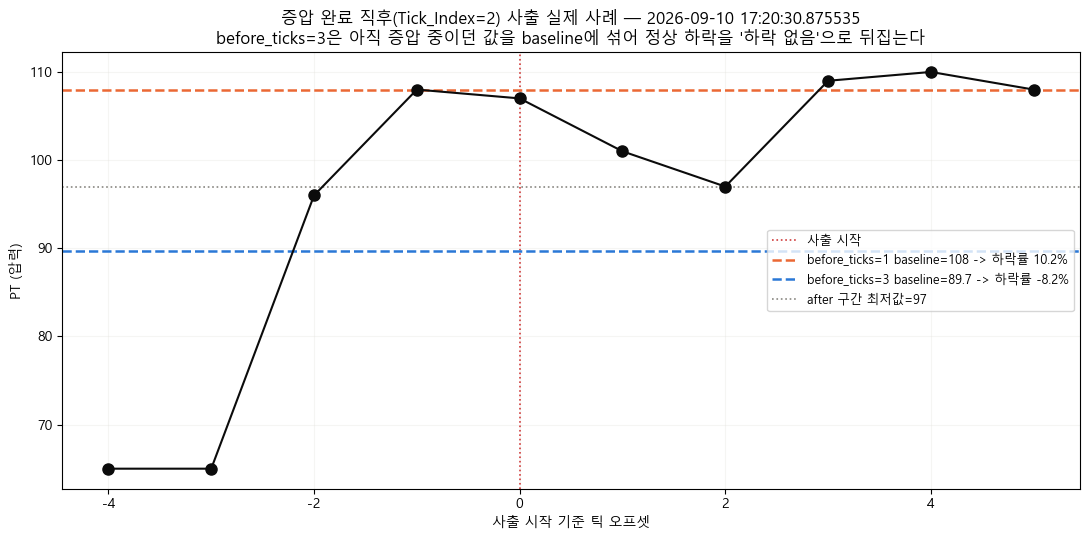

In [7]:
s_h = 8914  # 실제 사례: Tick_Index=2 (증압 완료 직후) 사출
offs2 = list(range(-4, 6))
vals2 = [pt_all[s_h + o] for o in offs2]
base1 = pt_all[s_h - 1]
base3 = pt_all[s_h - 3:s_h].mean()
min_after = pt_all[s_h:s_h + 5].min()
t0 = pd.Timestamp(times[s_h])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(offs2, vals2, marker="o", ms=8, color=INK, lw=1.5, zorder=3)
ax.axvline(0, color=RED, ls=":", lw=1.2, label="사출 시작")
ax.axhline(base1, color=ORANGE, lw=1.8, ls="--",
           label=f"before_ticks=1 baseline={base1:.0f} -> 하락률 {(base1-min_after)/base1*100:.1f}%")
ax.axhline(base3, color=BLUE, lw=1.8, ls="--",
           label=f"before_ticks=3 baseline={base3:.1f} -> 하락률 {(base3-min_after)/base3*100:.1f}%")
ax.axhline(min_after, color=MUTED, lw=1.2, ls=":", label=f"after 구간 최저값={min_after:.0f}")
ax.set_xlabel("사출 시작 기준 틱 오프셋"); ax.set_ylabel("PT (압력)")
ax.set_title(f"증압 완료 직후(Tick_Index=2) 사출 실제 사례 — {t0}\n"
             f"before_ticks=3은 아직 증압 중이던 값을 baseline에 섞어 정상 하락을 '하락 없음'으로 뒤집는다")
ax.legend(fontsize=9, loc="center right")
ax.grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/H_ramp_contamination_example.png", dpi=140)
plt.show()

**정확히 이 메커니즘이다**: 사이클이 막 증압을 끝낸 시점(오프셋 -1, PT=108)에
사출이 시작된다. `before_ticks=1`은 이 108을 그대로 기준선으로 써서 **정상적인
10.2% 하락**을 잡아낸다. 반면 `before_ticks=3`은 오프셋 -3,-2,-1(65, 96, 108)의
평균(89.7)을 기준선으로 쓰는데, 이 중 두 틱(65, 96)은 **아직 증압이 안 끝난
낮은 값**이다. 그 결과 기준선이 실제보다 낮게 잡혀서, 똑같은 최저값(97)인데도
**"-8.2%"(압력이 오히려 올랐다)로 뒤집힌다.** 1-2절에서 "6.54% 하락 없음 오탐의
99.1%가 Tick_Index<=3"이라고 한 게 바로 이 현상이다.

(참고: 이보다 더 이른 Tick_Index=0 사례, 즉 증압이 사출과 거의 동시에 끝나는
극단적인 경우는 `before_ticks=1`로도 못 잡는다 - 2-1절 "나머지 0.08%" 중 13건이
여기 해당하고, 이건 baseline 창 크기로는 해결이 안 되는 별도의 경계 케이스다.)

### 2-1-2. 왜 "99.96%"인가 — 전체 분포로 직접 확인

지금까지는 "하락 없음"인 28건만 따로 들여다봤다. 이번엔 반대로 - 전체 33,989건이
실제로 어떻게 분포하길래 그 28건이 이렇게 예외적으로 적어 보이는지, 분포 전체를
그려서 확인한다.

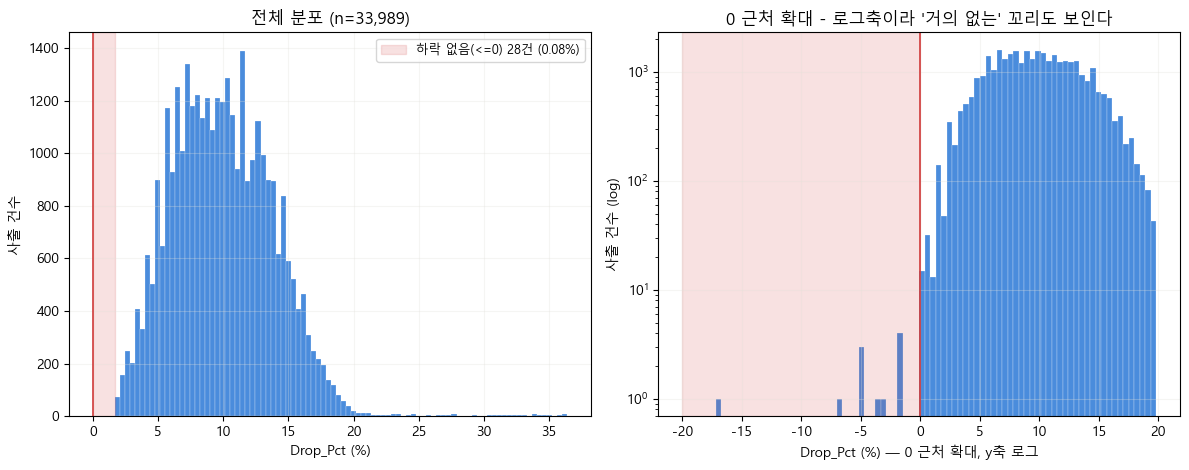

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
vals_full = ev["Drop_Pct"]
lo, hi = np.percentile(vals_full, [0.5, 99.5])
axes[0].hist(vals_full, bins=90, range=(lo, hi), color=BLUE, alpha=.85, edgecolor="white", linewidth=.2)
axes[0].axvspan(lo, 0, color=RED, alpha=.15,
                label=f"하락 없음(<=0) {(vals_full<=0).sum()}건 ({(vals_full<=0).mean()*100:.2f}%)")
axes[0].axvline(0, color=RED, lw=1.2)
axes[0].set_xlabel("Drop_Pct (%)"); axes[0].set_ylabel("사출 건수")
axes[0].set_title(f"전체 분포 (n={len(ev):,})")
axes[0].legend(fontsize=9); axes[0].grid(alpha=.3, color=GRID)

zoom = vals_full[(vals_full > -20) & (vals_full < 20)]
axes[1].hist(zoom, bins=80, color=BLUE, alpha=.85, edgecolor="white", linewidth=.2)
axes[1].axvspan(-20, 0, color=RED, alpha=.15)
axes[1].axvline(0, color=RED, lw=1.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("Drop_Pct (%) — 0 근처 확대, y축 로그")
axes[1].set_ylabel("사출 건수 (log)")
axes[1].set_title("0 근처 확대 - 로그축이라 '거의 없는' 꼬리도 보인다")
axes[1].grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/I_full_distribution_evidence.png", dpi=140)
plt.show()

**왜 99.96%나 되는가 - 물리적으로 당연한 이유**: 사출은 펌프가 관로에 있던 액체를
밀어내는 순간이다. 액체가 빠져나가는 그 짧은 순간 관로 안 압력(PT)은 물리적으로
낮아질 수밖에 없다 - 안 낮아지려면 펌프가 그만큼 더 빠르게 밀어 넣어 압력을
유지해야 하는데, 사출은 짧고(평균 2.4틱) 급격해서 그 보상이 못 따라간다. 그래서
"압력이 안 떨어지는 사출"이 있으려면 **오히려 뭔가 비정상**이어야 한다 - 예를 들면
(a) 노즐/밸브가 막혀서 액체가 실제로는 거의 안 나갔거나, (b) 이번에 찾은 것처럼
baseline을 잘못 재서 원래 있던 하락을 놓친 경우다. 왼쪽 히스토그램을 보면 실제
분포도 이 물리적 직관과 맞다 - 대부분 5~20% 사이에 뭉쳐 있고 0 아래는 거의 없다.
오른쪽(로그축) 확대에서도 음수 쪽은 막대가 1~4개짜리 낱개로만 드문드문 있다 -
"흔한 현상"이 아니라 "예외"라는 뜻이다. 그래서 그 예외 28건(0.08%) 중에서도
baseline 문제로 설명이 안 되는 15건(0.04%, 위 2-1절)이 **"압력이 안 떨어지면
문제로 봐도 된다"**는 이번 질문의 가장 직접적인 후보가 된다.

### 2-2. 압력대별 기대 하락률 — 고정 임계값이 아니라 조건부 기준이 필요

1-1절에서 이미 확인했듯 압력대마다 평균이 다르다. 표준편차도 다르므로(heteroscedastic),
"몇 % 이상 떨어지면 이상"을 고정값으로 잡으면 안 된다.

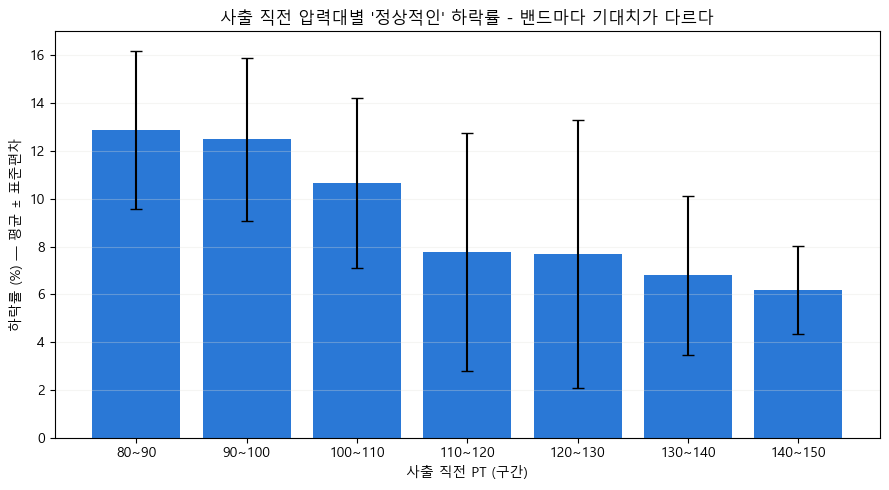

,n,mean,std,p1,p99
PT_Bin,,,,,
"(80, 90]",2219,12.89,3.31,5.62,19.10
"(90, 100]",10501,12.49,3.41,5.15,19.39
"(100, 110]",7692,10.68,3.56,3.74,17.48
"(110, 120]",4644,7.77,5.00,1.69,31.67
"(120, 130]",6470,7.70,5.62,1.63,40.75
"(130, 140]",2084,6.79,3.33,2.04,11.45
"(140, 150]",351,6.18,1.86,2.10,10.31


In [9]:
edges = np.arange(80, 160, 10)
ev["PT_Bin"] = pd.cut(ev["PT_Before"], edges)
band = ev.groupby("PT_Bin", observed=True)["Drop_Pct"].agg(
    n="size", mean="mean", std="std",
    p1=lambda s: np.percentile(s, 1), p99=lambda s: np.percentile(s, 99))
band.to_csv(f"{OUT}/drop_pct_by_pt_band_{PUMP_ID}.csv", encoding="utf-8-sig")

labels = [f"{int(iv.left)}~{int(iv.right)}" for iv in band.index]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels, band["mean"], yerr=band["std"], color=BLUE, capsize=4)
ax.set_xlabel("사출 직전 PT (구간)")
ax.set_ylabel("하락률 (%) — 평균 ± 표준편차")
ax.set_title("사출 직전 압력대별 '정상적인' 하락률 - 밴드마다 기대치가 다르다")
ax.grid(alpha=.3, color=GRID, axis="y")
plt.tight_layout()
plt.savefig(f"{OUT}/A_drop_pct_by_pt_band.png", dpi=140)
plt.show()
band.round(2)

**80~100대는 평균 12~13% ± 3.3% 떨어지고, 130~150대는 평균 6~7% ± 2~3%만
떨어진다** - 3배 가까이 차이난다. 그래서 이 피처를 쓰려면 `Cycle_Normalizer.
ResidualNormalizer` 방식(위치+흩어짐 둘 다 기준변수로 회귀 후 표준화 잔차화) 그대로
`PT_Before`를 기준변수로 써야 한다 - 마침 `Shot_Feature_Extractor.
SHOT_NORMALIZE_SPECS`에 `PT_Dip_Size: ["PT_Baseline_Before"]`로 이미 이렇게 설계돼
있다 (3절에서 이어서 다룸).

### 2-3. "너무 많이 떨어진" 사출 — 다른 발견과 교차검증되는가

밴드별 평균의 2~3배가 넘는(30% 초과) 극단적 하락이 실제로 뭔가를 의미하는지,
아니면 그냥 흩어짐의 꼬리인지 시간축에 놓고 본다.

In [10]:
extreme = ev[ev["Drop_Pct"] > 30].copy()
extreme["Date"] = pd.to_datetime(extreme["Time"]).dt.date
print(f"극단적 하락(>30%): {len(extreme)}건 / 전체 {len(ev):,}건 ({len(extreme)/len(ev)*100:.2f}%)")
print()
print("날짜별 극단치 건수:")
print(extreme.groupby("Date").size())

극단적 하락(>30%): 256건 / 전체 33,989건 (0.75%)

날짜별 극단치 건수:
Date
2026-09-11    25
2026-09-12    16
2026-09-14    73
2026-09-15    18
2026-09-16    17
2026-09-17    31
2026-09-18    22
2026-09-19    50
2026-09-21     4
dtype: int64


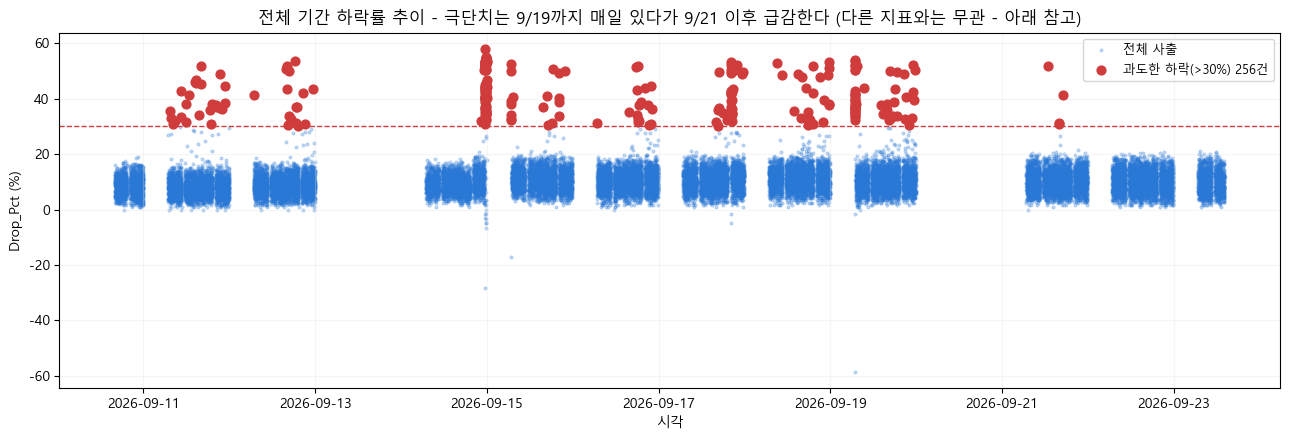

In [11]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.scatter(pd.to_datetime(ev["Time"]), ev["Drop_Pct"], s=4, color=BLUE, alpha=.25, label="전체 사출")
ax.scatter(pd.to_datetime(extreme["Time"]), extreme["Drop_Pct"], s=40, color=RED, zorder=5,
           label=f"과도한 하락(>30%) {len(extreme)}건")
ax.axhline(30, color=RED, ls="--", lw=1)
ax.set_ylabel("Drop_Pct (%)"); ax.set_xlabel("시각")
ax.set_title("전체 기간 하락률 추이 - 극단치는 9/19까지 매일 있다가 9/21 이후 급감한다 (다른 지표와는 무관 - 아래 참고)")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/C_extreme_drop_timeline.png", dpi=140)
plt.show()

**정정 — 다른 지표와의 교차검증은 실제로 계산해보니 성립하지 않았다.** 처음엔
`Injection_PT_Dip_Analysis.ipynb`의 "설명 안 되는 하락"(교정 후 127건) 일별 추이와
여기 극단적 사출-하락(>30%)이 같은 시기에 나타났다 사라진다고 썼는데, 두 일별
시계열의 상관계수를 직접 계산해보니 **-0.29**(교정 후 127건 기준) /
**+0.19**(교정 전 15,548건 기준)로 둘 다 약하다 - 그 주장은 근거 부족이라 철회한다.
`unexplained_pt_dip`은 9/21·9/22에 오히려 13건으로 그 구간 중 제일 높아서, 여기
극단치 추이와는 실제로 무관하게 움직인다.

**그래도 남는 건 이 지표 자체의 추이다.** 극단적 사출-하락(>30%)은 9/10~9/19엔
매일 16~73건씩 나오다가 9/21엔 4건, 9/22~23엔 0건으로 뚝 끊긴다. 다른 지표가
뒷받침해주는 건 아니지만, 이 하나만 놓고 봐도 "매일 일정 비율로 나는 노이즈"라기엔
너무 뚜렷한 단절이라 9/20(가동 없는 날)을 기점으로 뭔가 바뀌었을 가능성은 있다 -
다만 이건 가설일 뿐, 교차검증된 결론은 아니라는 점을 분명히 해둔다.

### 2-4. P1이 쏘면 P2 압력도 바뀔까? — 아니다, 각자 자기 것만 바뀐다

`head_foaming`을 왜 "제외 마스크"로만 쓰고 "품질 지표"엔 안 쓰는지 그 이유를
직접 확인한다. P1 데이터(캐시)와 P2 데이터(InfluxDB에서 직접 받음)를 같은 시간축에
합쳐서, **P1이 쏠 때 P2 자신의 압력(PT_P2)도 같이 떨어지는지**, 그 반대도
그런지를 사출 시점 정렬 평균으로 본다.

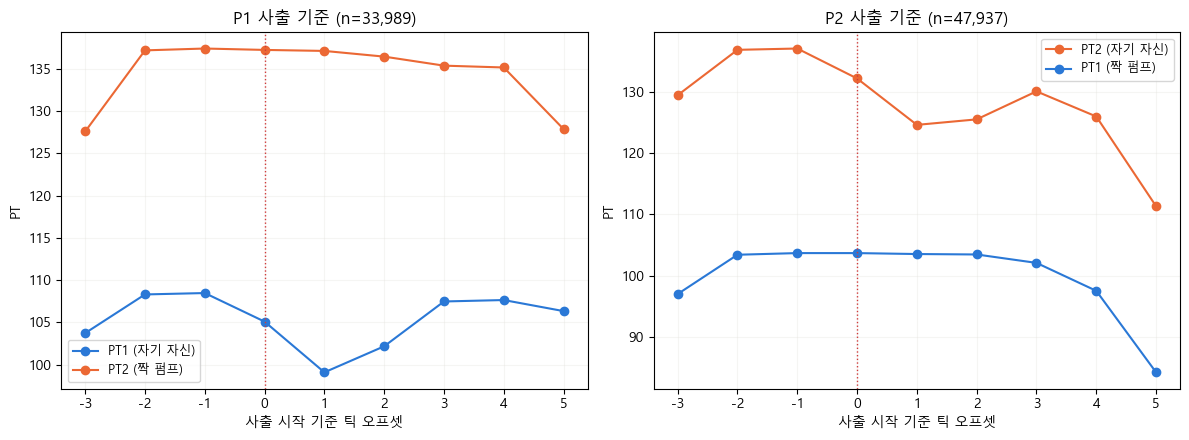

In [12]:
combo = pd.read_pickle("cache/combo_p1_p2.pkl")  # P1+P2 합쳐서 시간축 통일 + ffill 해둔 것

pt1 = combo["Scale_Out___PT_P1"].values
pt2 = combo["Scale_Out___PT_P2"].values
inj1 = (combo["Shot_Injection_HD1_P1"] != 0).values
inj2 = (combo["Shot_Injection_HD1_P2"] != 0).values
starts1 = np.where(inj1 & ~np.r_[False, inj1[:-1]])[0]
starts2 = np.where(inj2 & ~np.r_[False, inj2[:-1]])[0]

offs2 = list(range(-3, 6))
def profile(vals, starts):
    return np.array([vals[np.clip(starts + o, 0, len(vals) - 1)].mean() for o in offs2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
axes[0].plot(offs2, profile(pt1, starts1), "o-", color=BLUE, label="PT1 (자기 자신)")
axes[0].plot(offs2, profile(pt2, starts1), "o-", color=ORANGE, label="PT2 (짝 펌프)")
axes[0].axvline(0, color=RED, ls=":", lw=1)
axes[0].set_title(f"P1 사출 기준 (n={len(starts1):,})")
axes[1].plot(offs2, profile(pt2, starts2), "o-", color=ORANGE, label="PT2 (자기 자신)")
axes[1].plot(offs2, profile(pt1, starts2), "o-", color=BLUE, label="PT1 (짝 펌프)")
axes[1].axvline(0, color=RED, ls=":", lw=1)
axes[1].set_title(f"P2 사출 기준 (n={len(starts2):,})")
for ax in axes:
    ax.set_xlabel("사출 시작 기준 틱 오프셋"); ax.set_ylabel("PT")
    ax.legend(fontsize=9); ax.grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/D_p1_p2_cross_talk.png", dpi=140)
plt.show()

**결과**: P1이 쏠 때 PT1(자기 압력)은 뚜렷하게 떨어졌다 회복하는데, PT2(짝 펌프
압력)는 그 구간에서 거의 평평하다(완만하게 조금씩 내려갈 뿐, 사출 시점에 맞춰
꺾이지 않는다). P2가 쏠 때도 마찬가지로 PT1은 평평하다. **즉 한쪽 펌프가 쏜다고
다른 쪽 펌프의 압력 센서가 같이 뚜렷하게 떨어지지는 않는다** - 두 펌프는 서로
다른 라인/센서를 쓰는 것으로 보이고, 직접적인 "물리적 간섭"은 평균적으로는 안
보인다.

그런데 하나 더 확인할 게 있다 - FOAMING 교정으로 "설명됨"으로 재분류된 15,421건
중 80%가 P2 사출 시점에서 1.5초(~3틱) 이내였다(우연이라기엔 너무 잦다). 그래서
그 재분류된 건들의 하락폭을 "P2 사출 근처였는지 아닌지"로 나눠서 비교했다 -
근처였던 것(평균 4.23%)과 아니었던 것(평균 4.22%)이 **거의 똑같다**. 즉 P2
사출이 근처에 있다고 해서 PT1이 유난히 더 크게 흔들리는 게 아니다 - 그냥 사출/
접근/감쇠로 "바쁜" 구간 전반에 걸쳐 원래도 있던 작은(3~4%대) 잡음이 그 타이밍과
겹쳐 보일 뿐이다.

**결론**: 지금 사용자가 제안한 대로("그냥 처음부터 head_foaming으로 잡는 게 낫지
않냐")는 **"설명 안 되는 하락을 찾는" 목적에는 맞는 말이다** - 실제로 그렇게
고쳤다(이미 반영됨). 하지만 "이 펌프의 이 사출에 압력이 제대로 반응했는가"를
재는 목적에는 안 맞는다 - PT1은 P2가 쏠 때 반응하지 않으므로, PT1의 반응 크기를
재는 기준은 P1 자신의 `Shot_Injection_HD1_P1`이어야 정확하다. 두 목적이 다르기
때문에 신호도 다르게 써야 한다는 뜻이지, `head_foaming` 하나로 퉁칠 수 있는
문제는 아니다.

### 2-5. `head_foaming` 기준으로 봐도 될까? — "품질 지표"로는 안 된다, 이유

3부(FOAMING 교정)에서 확인했듯 `HD1_FOAMING_SHOT1~6`은 **헤드 공용**이라 한 에피소드
안에 P1·P2 사출이 같이 들어있는 경우가 95.9%다. 위 2-4절에서 확인했듯 P1·P2는
서로의 압력에 물리적으로 반응하지 않으므로:

- **"압력이 설명 안 되게 떨어졌나"(제외 마스크)** 용도로는 FOAMING이 맞다 -
  내 펌프가 안 쐈어도 짝 펌프의 접근/사출/감쇠 구간과 겹치면 그 잡음은 정상
  범위이니 빼야 한다. *(이미 반영함)*
- 하지만 **"이 사출에 압력이 제대로 반응했나"(품질 지표)** 용도로는 FOAMING을 쓰면
  안 된다 - 애초에 짝 펌프의 사출은 내 압력에 반응을 안 남기므로, FOAMING 시작
  시점을 기준으로 삼으면 반응 크기 자체를 잴 수가 없다. 이 목적엔 **펌프 자신의
  `Shot_Injection_{head}_P{slot}`**을 기준점으로 써야 한다 (지금 2-1~2-3절에서
  한 것처럼).

### 2-6. 반대 방향 — 인젝션 신호 없는데 압력이 떨어지는 경우는 어떻게 잡는가

지금까지(2-1~2-5)는 전부 "인젝션이 떴는데 압력이 안 떨어짐(또는 과하게 떨어짐)"
방향이었다. **반대 방향, 즉 "인젝션 신호가 없는데 압력이 떨어지는 경우"도 따로
찾아봤다** - 이게 오히려 원래 조사의 출발점이었다(`Injection_PT_Dip_Analysis.ipynb`,
`Cycle_Feature_Extractor.Unexplained_PT_Dip_Count`). 여기서는 그 방법과 최종
결과만 다시 정리한다 - 상세 과정은 그 노트북에 있다.

**어떻게 잡는가 (`Injection_Dip_Analyzer.unexplained_pt_dip_events`)**:
1. 가동 중(`Pump_BuildUp==1`)인 모든 틱에 대해, **직전 3틱 롤링평균**을 baseline으로
   잡는다 (이건 "이 사출이 얼마나 떨어졌나"를 재는 2-1절의 baseline과는 다른
   목적이라 - 매 틱마다 "방금 평소와 달랐나"를 보는 것이라 3틱 롤링이 맞다. 앞서
   본 것처럼 baseline이 넓으면 왜곡되는 문제는 여기도 있어서, 감쇠 구간(사이클
   끝 2틱 이내)은 별도로 배제한다).
2. 그 baseline 대비 **3% 이상 하락**하면 1차 후보.
3. 다음 네 가지 **"설명됨" 마스크**에 걸리면 후보에서 뺀다 - 걸리면 정상이라는
   뜻이다:
   - `Shot_Owned_Active`: 이 펌프 자신의 `Shot_Injection_*` +4틱 이내
   - `Foaming_Active`: 같은 헤드의 `HD1_FOAMING_SHOT1~6` (짝 펌프 포함) 켜짐
   - `SV_Changed_Recent`: 직전 3틱 안에 SV(레시피) 자체가 바뀜
   - `Near_Cycle_End`: 사이클 마지막 2틱 이내(펌프 꺼지기 직전 감쇠)

넷 다 아닌데도 3% 이상 떨어진 게 최종 후보(`Strong_Candidate`)다.

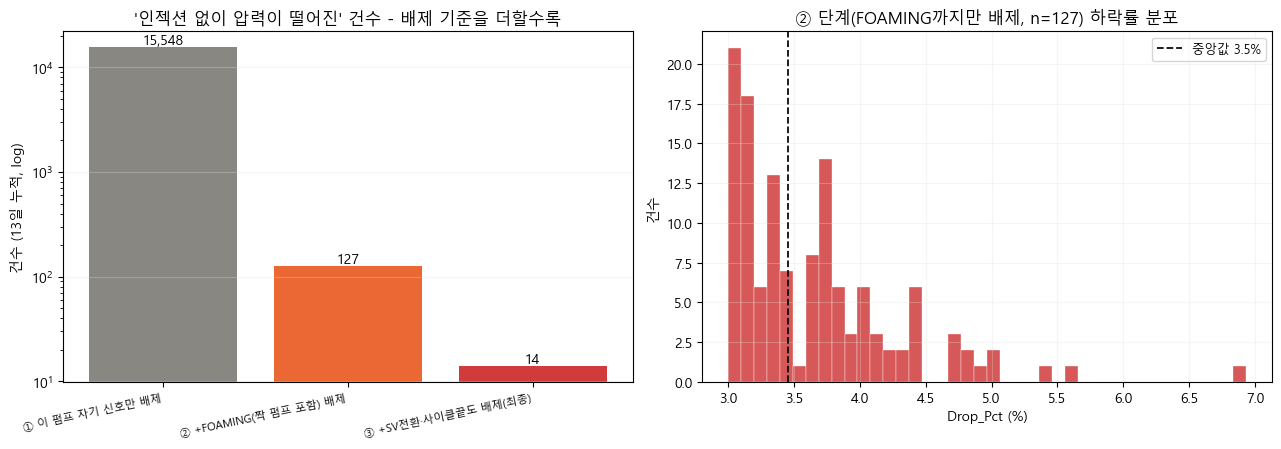

최종 후보(Strong_Candidate) 14건 - 13일 전체:


,Time,Cycle_ID,Tick_Index,PT_Now,PT_Prev_Roll,Drop_Abs,Drop_Pct
8,2026-09-11 06:33:05.239943,2742,69,149.0,155.000000,6.000000,3.870968
6,2026-09-11 06:31:06.234816,2740,9,148.0,153.666667,5.666667,3.687636
103,2026-09-21 15:25:11.253959,54230,6,134.0,139.666667,5.666667,4.057279
40,2026-09-15 15:25:55.502352,23866,32,132.0,137.666667,5.666667,4.116223
9,2026-09-11 06:33:08.946865,2742,76,149.0,154.333333,5.333333,3.455724
13,2026-09-12 06:30:22.819788,8636,5,159.0,164.000000,5.000000,3.048780
109,2026-09-22 06:29:40.970162,57178,9,143.0,148.000000,5.000000,3.378378
76,2026-09-17 23:40:40.575239,38932,3,88.0,93.000000,5.000000,5.376344
121,2026-09-22 22:07:47.479006,63158,12,106.0,110.666667,4.666667,4.216867
7,2026-09-11 06:32:54.227537,2742,50,149.0,153.666667,4.666667,3.036876


In [13]:
legacy_ev = D.unexplained_pt_dip_events_legacy(raw, PUMP_ID)  # Foaming 배제 넣기 전 (비교용)

funnel = pd.DataFrame({
    "단계": ["① 이 펌프 자기 신호만 배제", "② +FOAMING(짝 펌프 포함) 배제",
           "③ +SV전환·사이클끝도 배제(최종)"],
    "건수": [len(legacy_ev), len(dip_ev), int(dip_ev["Strong_Candidate"].sum())],
})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].bar(funnel["단계"], funnel["건수"], color=[MUTED, ORANGE, RED])
for i, v in enumerate(funnel["건수"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
axes[0].set_yscale("log")
axes[0].set_ylabel("건수 (13일 누적, log)")
axes[0].set_title("'인젝션 없이 압력이 떨어진' 건수 - 배제 기준을 더할수록")
axes[0].grid(alpha=.3, color=GRID, axis="y")
plt.setp(axes[0].get_xticklabels(), rotation=12, ha="right", fontsize=8)

axes[1].hist(dip_ev["Drop_Pct"], bins=40, color=RED, alpha=.85, edgecolor="white", linewidth=.3)
axes[1].axvline(dip_ev["Drop_Pct"].median(), color=INK, ls="--", lw=1.3,
                label=f"중앙값 {dip_ev['Drop_Pct'].median():.1f}%")
axes[1].set_xlabel("Drop_Pct (%)"); axes[1].set_ylabel("건수")
axes[1].set_title(f"② 단계(FOAMING까지만 배제, n={len(dip_ev)}) 하락률 분포")
axes[1].legend(fontsize=9); axes[1].grid(alpha=.3, color=GRID)
plt.tight_layout()
plt.savefig(f"{OUT}/J_unexplained_dip_funnel.png", dpi=140)
plt.show()

print(f"최종 후보(Strong_Candidate) {int(dip_ev['Strong_Candidate'].sum())}건 - 13일 전체:")
dip_ev[dip_ev["Strong_Candidate"]].sort_values("Drop_Abs", ascending=False)[
    ["Time", "Cycle_ID", "Tick_Index", "PT_Now", "PT_Prev_Roll", "Drop_Abs", "Drop_Pct"]]

**읽는 법**: 이 펌프 자기 신호만 보면 13일간 15,548건이나 "설명 안 됨"으로 잡히지만,
그중 99.2%는 FOAMING(짝 펌프 포함)이 켜져 있던 순간과 겹쳤다. **이건 P1·P2 압력이
서로 물리적으로 반응한다는 뜻이 아니다** - 2-4절에서 봤듯 평균적으로 P1은 P2의
사출에 반응하지 않는다. 실제로 뭘 뺀 건지 뜯어보면:

| 겹친 FOAMING 단계 | 비율 | 실체 |
|---|---|---|
| SHOT1 (접근) | 25.7% | 거의 다 P1 자신 - 자기 사출 신호가 뜨기도 전 단계 |
| SHOT2 (사출 인접) | 38.2% | 절반은 P1 자신의 회복 꼬리, 절반은 P2 사출과 시간상 근접 |
| SHOT3 (감쇠) | 34.1% | 절반 이상 P2 쪽 시간대 |
| SHOT4 | 2.0% | 거의 P2 쪽 |

즉 4분의 1은 애초에 P2와 무관한 **P1 자신의 확장된 접근 구간**이었다. 나머지도
"P2 사출과 시간상 가깝다"(80%가 1.5초 이내)일 뿐, 그 근처 하락폭이 더 크지도
않았다(근처 4.23% vs 아닌 곳 4.22%, 2-4절 참고) - 즉 **P2가 원인이 되어 더 크게
흔든 게 아니라, 원래 있던 잡음이 '바쁜 시간대'와 겹쳐 보였을 뿐**이다. 그걸 빼면
127건, 거기서 SV전환·사이클끝까지 더 빼면 **13일 통틀어 14건**만 남는다. 남은
127건의 하락률도 대부분 3~5% 사이의 작은 값(중앙값 3.5%)이라, 2-1절에서 본
"정상 사출의 하락률"(중앙값 9.8%)의 3분의 1 수준이다 - 즉 진짜 이상이라기보단
안정구간의 잔잔한 잡음(판정 임계치 3%를 겨우 넘는 수준)에 가깝다는 뜻이다.

**정리하면 두 방향을 다 본 것이다**:
- **인젝션 있는데 압력 반응 없음/과함** (이 노트북 2-1~2-5) - "이 사출이 제대로
  일 했나"를 보는 **샷 품질** 피처. 후보: `Shot_Feature_Extractor.PT_Dip_Size(_z)`.
- **인젝션 없는데 압력이 떨어짐** (이 절, 상세는 `Injection_PT_Dip_Analysis.ipynb`) -
  "설명 안 되는 압력 손실이 있었나"를 보는 **누출/이상** 피처. 이미
  `Cycle_Feature_Extractor.Unexplained_PT_Dip_Count`로 존재하고, 이번에
  `Injection_Dip_Analyzer.unexplained_pt_dip_events()`가 FOAMING 배제(물리적
  인과가 아니라 "이 순간은 바빴다"는 시간적 마스킹)를 반영해서 교정했다.

둘은 서로 반대 방향이라 하나로 합칠 수 없고, 마스크(무엇을 "설명됨"으로 볼지)도
용도에 따라 다르게 써야 한다는 게 이번 조사 전체의 핵심이었다.

## 3. 결론 및 제안

**질문에 대한 답**: 그렇다, 압력 하락은 사출을 상당히 명확하게 반영한다
(99.96%가 어떤 형태로든 떨어짐). 극단치(>30%) 자체의 시간 추이는 뚜렷하지만
다른 지표와의 교차검증은 되지 않았다(위 2-3절 정정 참고). **압력이 안 떨어지거나
(거의 0) 너무 많이 떨어지면(밴드 대비 이상치) "문제"로 취급하는 건 여전히
통계적으로 근거가 있다** - 다만 "극단치가 다른 지표로도 검증됐다"는 아니고
"관계 자체가 타이트하고 압력대별 기대치가 명확하다"는 근거다.

**이미 존재하는 피처와의 관계**: `Shot_Feature_Extractor.py`에 이미 이 개념이
`PT_Dip_Size`(하락폭) -> `PT_Dip_Size_z`(압력대 보정 잔차, `ResidualNormalizer`로
`PT_Baseline_Before` 기준 정규화)로 구현돼 있고, `Shot_AE`가 이걸로 이미 학습돼
있다(`models_shot/`). **다만 `BASELINE_TICKS=3`**(현재 코드)**이 이번에 찾은 것과
똑같은 문제**를 갖고 있다 - 증압 중(Tick_Index 낮음)에 일어난 사출의 baseline이
오염돼 `PT_Dip_Size`가 실제보다 작게(또는 음수로) 나올 수 있다.

**제안 (실행은 별도 확인 후)**:
1. `Shot_Feature_Extractor.BASELINE_TICKS`를 3 -> 1로 줄인다.
2. 사출이 일어난 사이클 내 위치(`Tick_Index`)를 `extract_shot_features`에 컬럼으로
   추가하고, 증압 미완료 구간(대략 Tick_Index<=1~3)에서 일어난 샷은 별도 플래그로
   표시하거나 학습에서 제외한다.
3. 이 수정 후 `Shot_AE`를 재학습해서 이상률이 어떻게 바뀌는지 확인한다
   (`SV_유량_추종_분석.ipynb`도 같은 제안을 하면서 "이상탐지 성능으로 검증한 게
   아니니 재학습 후 봐야 한다"고 못박아뒀다 - 같은 원칙 적용).
4. `HD1_FOAMING_SHOT`은 "제외 마스크"(누출/이상 탐지용)로만 쓰고, "샷 품질"
   피처에는 쓰지 않는다.

## 정리

| 항목 | 결론 |
|---|---|
| 사출→압력하락 관계가 타이트한가 | 그렇다 (99.96%가 하락, 0.04%만 완전 무반응) |
| 고정 임계값이 적당한가 | 아니다 - 압력대별 평균 6~13%, 표준편차도 다름 -> 조건부(정규화) 필요 |
| 극단치가 의미 있는 신호인가 | 추세 자체는 뚜렷하다(9/19까지 매일, 9/21 이후 급감). 단 다른 지표와의 교차검증은 상관계수 -0.29/+0.19로 약해서 철회함 |
| P1↔P2 물리적 간섭이 있는가 | 없다 - 각 펌프 신호는 자기 펌프 압력만 떨어뜨린다(평균 프로파일로 확인). FOAMING 배제가 필요했던 건 간섭 때문이 아니라 각 펌프 자신의 접근/감쇠가 ±4틱보다 길어서였다 |
| head_foaming 기준으로 재도 되는가 | 안 된다(품질 지표 용도로는) - P1·P2 결합이라 "내 샷의 반응"을 못 가른다. 제외 마스크 용도로만 적합 |
| 피처로 쓸 수 있는가 | **그렇다** - 단, baseline을 1틱으로, 압력대 보정을 반드시 포함해서 |
| 기존 구현 | `Shot_Feature_Extractor.PT_Dip_Size(_z)` 이미 있음 - `BASELINE_TICKS=3` 버그만 고치면 됨 |

출력: `analysis_out/injection_pt_feature/` (그림 3개 + CSV 1개).